# Telco Customer Churn Prediction
## Machine Learning Analysis Notebook

This notebook performs a complete data analysis and machine learning pipeline on the Telco Customer Churn dataset. The goal is to predict whether a customer will churn (leave the service) using logistic regression and random forest models.

**Dataset Overview:**
- Source: IBM Sample Data Sets (Telco industry)
- 7,043 customers with 21 attributes
- Target variable: `Churn` (Yes/No)

---
## Phase 1: Library Imports

In [1]:
# Import essential libraries for data analysis, visualization, and machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay
)

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
%matplotlib inline

---
## Phase 2: Data Inspection

### Step 4: Display the first ten rows of the dataset

In [3]:
# Load the Telco Customer Churn dataset from the provided CSV file
# The dataset should be in the same folder as this notebook
df = pd.read_csv('Telco-Customer-Churn.csv')

# Display the first 10 rows to understand the data structure
print("First 10 rows of the dataset:")
df.head(10)

First 10 rows of the dataset:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


### Step 5: Output the names of the dataset's columns

In [4]:
# List all column names to understand available features
print("Dataset Columns:")
print(df.columns.tolist())
print(f"\nTotal number of columns: {len(df.columns)}")

Dataset Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Total number of columns: 21


### Step 6: Display the data types of each column

In [5]:
# Display data types to identify which columns need preprocessing
print("Data types of each column:")
print(df.dtypes)
print(f"\nDataset shape: {df.shape}")

Data types of each column:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Dataset shape: (7043, 21)


---
## Phase 3: Data Preprocessing

### Step 7: Convert the "TotalCharges" column to numeric data type

In [6]:
# TotalCharges is loaded as object (string) because some values may be empty strings
# Convert to numeric, coercing errors to NaN for later removal
print(f"TotalCharges dtype before conversion: {df['TotalCharges'].dtype}")

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f"TotalCharges dtype after conversion: {df['TotalCharges'].dtype}")
print(f"Number of missing values after conversion: {df['TotalCharges'].isna().sum()}")

TotalCharges dtype before conversion: str
TotalCharges dtype after conversion: float64
Number of missing values after conversion: 11


### Step 8: Remove rows with missing values from the dataset

In [7]:
# Drop any rows containing missing values to ensure clean data for modeling
print(f"Dataset shape before removing missing values: {df.shape}")

# Remove rows with any NaN values
df = df.dropna()

print(f"Dataset shape after removing missing values: {df.shape}")

Dataset shape before removing missing values: (7043, 21)
Dataset shape after removing missing values: (7032, 21)


### Step 9: Remove the "customerID" column from the dataset

In [8]:
# customerID is a unique identifier with no predictive value for churn
# Removing it prevents the model from learning spurious patterns
df = df.drop('customerID', axis=1)

print(f"customerID column removed. Remaining columns: {len(df.columns)}")
print("Remaining columns:", df.columns.tolist())

customerID column removed. Remaining columns: 20
Remaining columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


### Step 10: Convert the "Churn" column to binary numeric values

In [9]:
# Convert target variable to binary: Yes -> 1 (churned), No -> 0 (not churned)
# This format is required for machine learning algorithms
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Churn value counts after conversion:")
print(df['Churn'].value_counts())
print(f"\nChurn rate: {df['Churn'].mean():.2%}")

Churn value counts after conversion:
Churn
0    5163
1    1869
Name: count, dtype: int64

Churn rate: 26.58%


### Step 11: Convert all categorical variables into dummy variables

In [11]:
# Identify categorical columns (all object-type columns remaining)
categorical_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()

print(f"Categorical columns to convert: {categorical_cols}")
print(f"Number of categorical columns: {len(categorical_cols)}")

# Convert categorical variables to dummy/indicator variables
# drop_first=True avoids the dummy variable trap by removing one category per feature
# This prevents perfect multicollinearity which can cause issues in some algorithms
telecom_cust_dummies = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(f"\nShape after dummy variable conversion: {telecom_cust_dummies.shape}")
print(f"Original shape was: {df.shape}")
print(f"Number of new columns created: {telecom_cust_dummies.shape[1] - df.shape[1] + len(categorical_cols)}")

Categorical columns to convert: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Number of categorical columns: 15

Shape after dummy variable conversion: (7032, 31)
Original shape was: (7032, 20)
Number of new columns created: 26


---
## Phase 4: Data Visualisation

### Step 12: Create a correlation plot to visualise correlation with "Churn"

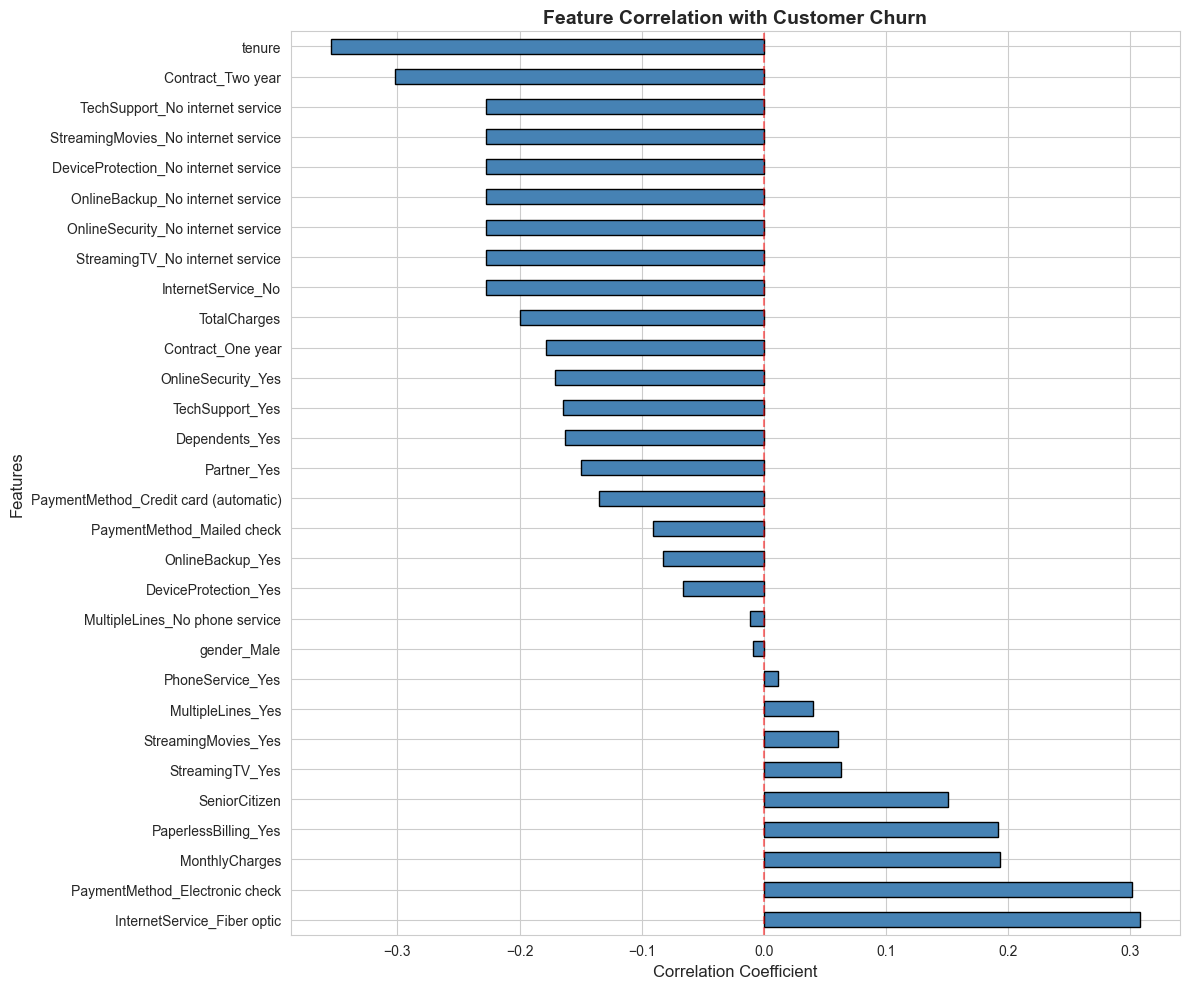

Top 5 positive correlations with Churn:
InternetService_Fiber optic       0.307463
PaymentMethod_Electronic check    0.301455
MonthlyCharges                    0.192858
PaperlessBilling_Yes              0.191454
SeniorCitizen                     0.150541
Name: Churn, dtype: float64

Top 5 negative correlations with Churn:
DeviceProtection_No internet service   -0.227578
StreamingMovies_No internet service    -0.227578
TechSupport_No internet service        -0.227578
Contract_Two year                      -0.301552
tenure                                 -0.354049
Name: Churn, dtype: float64


In [12]:
# Calculate correlation of all features with the target variable Churn
correlations = telecom_cust_dummies.corr()['Churn'].sort_values(ascending=False)

# Create a horizontal bar plot of correlations
plt.figure(figsize=(12, 10))
correlations.drop('Churn').plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Feature Correlation with Customer Churn', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Display top positive and negative correlations
print("Top 5 positive correlations with Churn:")
print(correlations.drop('Churn').head(5))
print("\nTop 5 negative correlations with Churn:")
print(correlations.tail(5))

### Step 13: Create a histogram of the "tenure" column

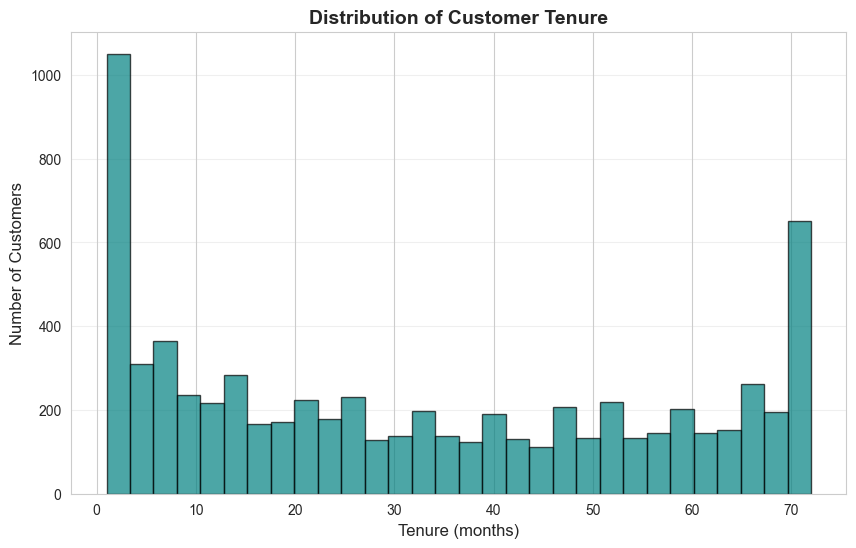

Tenure statistics:
count    7032.000000
mean       32.421786
std        24.545260
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64


In [13]:
# Visualise the distribution of customer tenure (how long they've been with the company)
plt.figure(figsize=(10, 6))
plt.hist(df['tenure'], bins=30, color='teal', edgecolor='black', alpha=0.7)
plt.title('Distribution of Customer Tenure', fontsize=14, fontweight='bold')
plt.xlabel('Tenure (months)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Tenure statistics:\n{df['tenure'].describe()}")

### Step 14: Create a scatter plot of "MonthlyCharges" vs "TotalCharges"

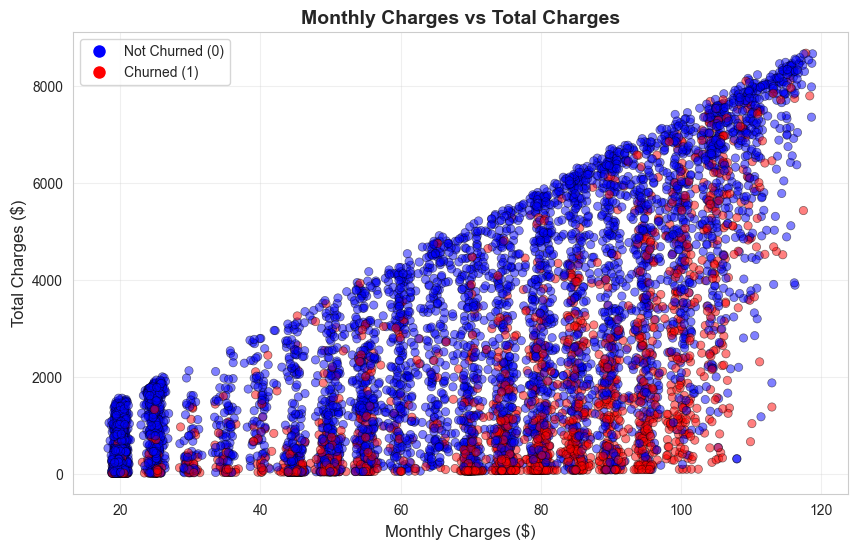

In [14]:
# Explore the relationship between monthly and total charges
# Color points by churn status to identify patterns
plt.figure(figsize=(10, 6))

# Create scatter plot with churn as color
churn_colors = df['Churn'].map({1: 'red', 0: 'blue'})
plt.scatter(df['MonthlyCharges'], df['TotalCharges'], 
            c=churn_colors, alpha=0.5, edgecolors='black', linewidth=0.5)

plt.title('Monthly Charges vs Total Charges', fontsize=14, fontweight='bold')
plt.xlabel('Monthly Charges ($)', fontsize=12)
plt.ylabel('Total Charges ($)', fontsize=12)

# Add custom legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', 
                           markersize=10, label='Not Churned (0)'),
                   Line2D([0], [0], marker='o', color='w', markerfacecolor='red', 
                           markersize=10, label='Churned (1)')]
plt.legend(handles=legend_elements, loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

### Step 15: Create a box plot to compare "tenure" for churned and non-churned customers

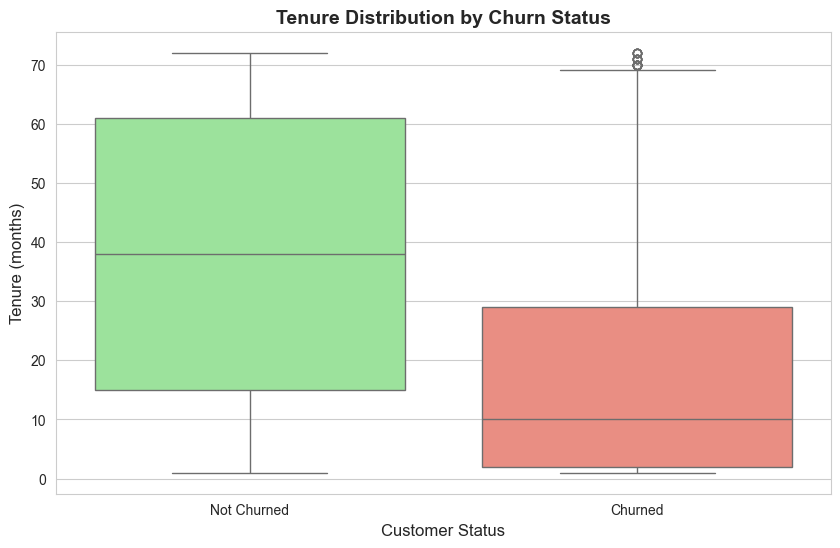

Tenure statistics by churn status:
        count       mean        std  min   25%   50%   75%   max
Churn                                                           
0      5163.0  37.650010  24.076940  1.0  15.0  38.0  61.0  72.0
1      1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0


In [15]:
# Compare tenure distributions between churned and non-churned customers
plt.figure(figsize=(10, 6))

# Create a temporary DataFrame with readable labels for the plot
df_plot = df.copy()
df_plot['Churn_Status'] = df_plot['Churn'].map({1: 'Churned', 0: 'Not Churned'})

# Create box plot comparing tenure by churn status
sns.boxplot(x='Churn_Status', y='tenure', data=df_plot, hue='Churn_Status',
            palette={'Churned': 'salmon', 'Not Churned': 'lightgreen'}, legend=False)

plt.title('Tenure Distribution by Churn Status', fontsize=14, fontweight='bold')
plt.xlabel('Customer Status', fontsize=12)
plt.ylabel('Tenure (months)', fontsize=12)
plt.show()

print("Tenure statistics by churn status:")
print(df.groupby('Churn')['tenure'].describe())

---
## Phase 5: Preparations for Machine Learning Training

### Step 16: Scale all variables to a range of 0 to 1 using min-max scaling

In [16]:
# Separate features (X) and target variable (y)
X = telecom_cust_dummies.drop('Churn', axis=1)
y = telecom_cust_dummies['Churn']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Apply Min-Max scaling to normalize all features between 0 and 1
# This ensures all features contribute equally to distance-based algorithms
scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame to preserve column names
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print(f"\nScaling complete. Feature ranges:")
print(f"Minimum value: {X_scaled.min().min():.4f}")
print(f"Maximum value: {X_scaled.max().max():.4f}")

Features shape: (7032, 30)
Target shape: (7032,)

Scaling complete. Feature ranges:
Minimum value: 0.0000
Maximum value: 1.0000


### Step 17: Split the dataset into training and test sets (25% test size)

In [17]:
# Split data into training (75%) and testing (25%) sets
# random_state ensures reproducibility; stratify maintains class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.25, 
    random_state=42,
    stratify=y  # Preserve churn ratio in both sets
)

print(f"Training set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(y):.1%})")
print(f"Test set size: {X_test.shape[0]} samples ({X_test.shape[0]/len(y):.1%})")
print(f"\nTraining set churn rate: {y_train.mean():.2%}")
print(f"Test set churn rate: {y_test.mean():.2%}")

Training set size: 5274 samples (75.0%)
Test set size: 1758 samples (25.0%)

Training set churn rate: 26.58%
Test set churn rate: 26.56%


---
## Phase 6: Logistic Regression Model

### Step 18: Import and train a logistic regression model on the training data

In [18]:
# Initialize and train logistic regression model
# max_iter increased to ensure convergence on this dataset
logreg = LogisticRegression(max_iter=1000, random_state=42)

# Fit the model on training data
logreg.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")
print(f"Number of features used: {logreg.n_features_in_}")
print(f"Number of iterations to converge: {logreg.n_iter_[0]}")

Logistic Regression model trained successfully.
Number of features used: 30
Number of iterations to converge: 24


### Step 19: Make predictions on the test data

In [19]:
# Generate predictions on the test set
y_pred_logreg = logreg.predict(X_test)

print("Predictions generated for test set.")
print(f"Predicted churn count: {np.sum(y_pred_logreg)}")
print(f"Predicted no-churn count: {len(y_pred_logreg) - np.sum(y_pred_logreg)}")

Predictions generated for test set.
Predicted churn count: 408
Predicted no-churn count: 1350


### Step 20: Calculate and print the accuracy score of the logistic regression model

In [20]:
# Evaluate logistic regression accuracy
logreg_accuracy = accuracy_score(y_test, y_pred_logreg)

print("=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)
print(f"Accuracy: {logreg_accuracy:.4f} ({logreg_accuracy:.2%})")
print("=" * 50)

LOGISTIC REGRESSION RESULTS
Accuracy: 0.8060 (80.60%)


---
## Phase 7: Random Forest Model

### Step 21: Create a random forest classifier with tuned hyperparameters

In [21]:
# Initialize Random Forest with specified hyperparameters:
# a. n_estimators=2000: Large ensemble of 2000 decision trees for robust predictions
# b. oob_score=True: Enable Out-of-Bag error estimation (built-in validation)
# c. max_features='sqrt': Consider sqrt(n_features) at each split for diversity
# d. max_leaf_nodes=50: Limit tree complexity to prevent overfitting
# e. bootstrap=True: Use bootstrapped samples for each tree
rf = RandomForestClassifier(
    n_estimators=2000,        # Number of trees in the forest
    oob_score=True,           # Enable OOB score for error estimation
    max_features='sqrt',      # Number of features to consider at each split
    max_leaf_nodes=50,        # Maximum leaf nodes per tree
    bootstrap=True,           # Use bootstrap samples
    random_state=42,          # For reproducibility
    n_jobs=-1                 # Use all available CPU cores
)

print("Random Forest classifier created with the following parameters:")
print(f"  - Number of estimators (trees): {rf.n_estimators}")
print(f"  - OOB score enabled: {rf.oob_score}")
print(f"  - Max features per split: {rf.max_features}")
print(f"  - Max leaf nodes: {rf.max_leaf_nodes}")
print(f"  - Bootstrap: {rf.bootstrap}")

Random Forest classifier created with the following parameters:
  - Number of estimators (trees): 2000
  - OOB score enabled: True
  - Max features per split: sqrt
  - Max leaf nodes: 50
  - Bootstrap: True


### Step 22: Fit the random forest model

In [22]:
# Train the random forest on the training data
rf.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


### Step 23: Make predictions on the test data

In [23]:
# Generate predictions using the trained random forest
y_pred_rf = rf.predict(X_test)

print("Random Forest predictions generated.")
print(f"Predicted churn count: {np.sum(y_pred_rf)}")
print(f"Predicted no-churn count: {len(y_pred_rf) - np.sum(y_pred_rf)}")

Random Forest predictions generated.
Predicted churn count: 335
Predicted no-churn count: 1423


### Step 24: Calculate and print the accuracy score of the random forest classifier

In [24]:
# Evaluate random forest accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("=" * 50)
print("RANDOM FOREST RESULTS")
print("=" * 50)
print(f"Accuracy: {rf_accuracy:.4f} ({rf_accuracy:.2%})")
print("=" * 50)

RANDOM FOREST RESULTS
Accuracy: 0.7918 (79.18%)


### Step 25: Calculate and print the OOB error estimation

In [25]:
# OOB (Out-of-Bag) error provides an internal validation estimate
# It uses the ~37% of samples not included in each tree's bootstrap sample
oob_score = rf.oob_score_
oob_error = 1 - oob_score

print("=" * 50)
print("OUT-OF-BAG (OOB) ERROR ESTIMATION")
print("=" * 50)
print(f"OOB Score (accuracy): {oob_score:.4f} ({oob_score:.2%})")
print(f"OOB Error:            {oob_error:.4f} ({oob_error:.2%})")
print("=" * 50)

print("\nOOB Error Interpretation:")
print("The OOB error estimates how well the model generalises to unseen data")
print("by using out-of-bag samples as an internal validation set.")
print(f"An OOB error of {oob_error:.2%} suggests the model correctly predicts")
print(f"approximately {(1-oob_error):.2%} of new observations without needing a separate validation set.")

OUT-OF-BAG (OOB) ERROR ESTIMATION
OOB Score (accuracy): 0.7992 (79.92%)
OOB Error:            0.2008 (20.08%)

OOB Error Interpretation:
The OOB error estimates how well the model generalises to unseen data
by using out-of-bag samples as an internal validation set.
An OOB error of 20.08% suggests the model correctly predicts
approximately 79.92% of new observations without needing a separate validation set.


---
## Phase 8: Enhanced Model Evaluation

### Step 26: Calculate the confusion matrix for both models

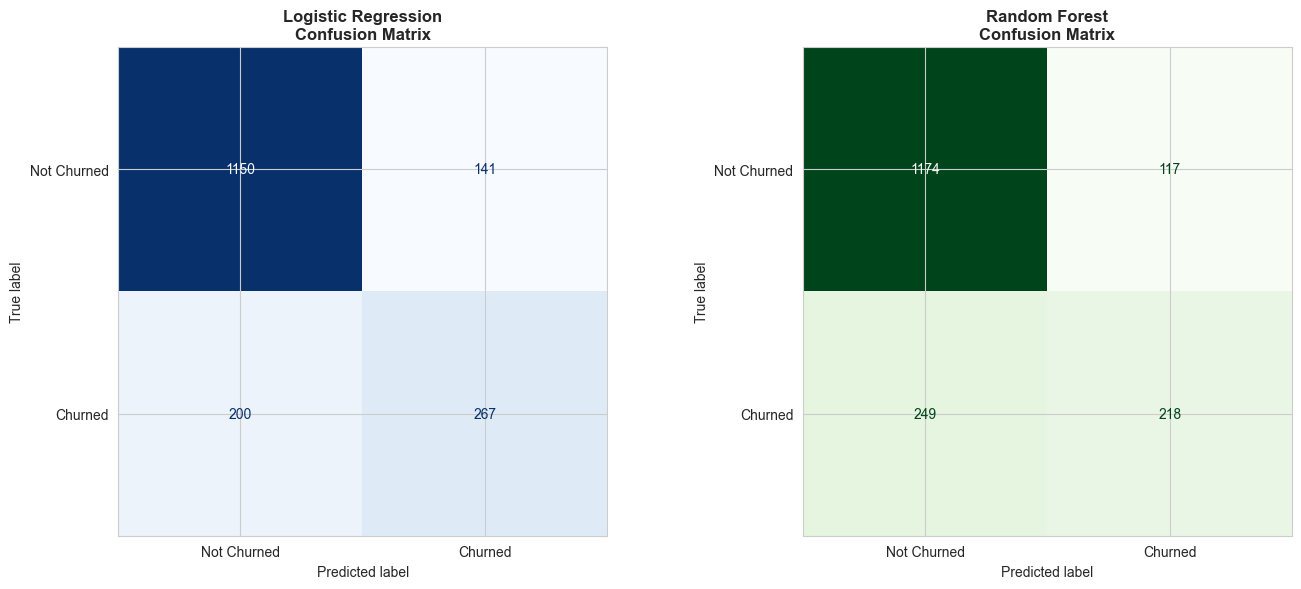

Logistic Regression Confusion Matrix:
[[1150  141]
 [ 200  267]]

Random Forest Confusion Matrix:
[[1174  117]
 [ 249  218]]


In [26]:
# Compute confusion matrices for both models
cm_logreg = confusion_matrix(y_test, y_pred_logreg)
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Create side-by-side confusion matrix plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Logistic Regression Confusion Matrix
disp_logreg = ConfusionMatrixDisplay(confusion_matrix=cm_logreg, 
                                      display_labels=['Not Churned', 'Churned'])
disp_logreg.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Logistic Regression\nConfusion Matrix', fontsize=12, fontweight='bold')

# Random Forest Confusion Matrix
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, 
                                display_labels=['Not Churned', 'Churned'])
disp_rf.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Random Forest\nConfusion Matrix', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("Logistic Regression Confusion Matrix:")
print(cm_logreg)
print(f"\nRandom Forest Confusion Matrix:")
print(cm_rf)

### Step 27: Compute precision and recall scores for each model

In [27]:
# Calculate precision and recall for both models
# Precision: Of predicted churners, how many actually churned?
# Recall: Of actual churners, how many did we correctly identify?

precision_logreg = precision_score(y_test, y_pred_logreg, zero_division=0)
recall_logreg = recall_score(y_test, y_pred_logreg, zero_division=0)

precision_rf = precision_score(y_test, y_pred_rf, zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf, zero_division=0)

print("=" * 60)
print("MODEL COMPARISON: PRECISION & RECALL")
print("=" * 60)
print(f"{'Metric':<<20} {'Logistic Regression':<<20} {'Random Forest':<<20}")
print("-" * 60)
print(f"{'Precision':<<20} {precision_logreg:<20.4f} {precision_rf:<20.4f}")
print(f"{'Recall':<<20} {recall_logreg:<20.4f} {recall_rf:<20.4f}")
print(f"{'Accuracy':<<20} {logreg_accuracy:<20.4f} {rf_accuracy:<20.4f}")
print("=" * 60)

MODEL COMPARISON: PRECISION & RECALL
Metric<<<<<<<<<<<<<< Logistic Regression< Random Forest<<<<<<<
------------------------------------------------------------
Precision<<<<<<<<<<< 0.6544               0.6507              
Recall<<<<<<<<<<<<<< 0.5717               0.4668              
Accuracy<<<<<<<<<<<< 0.8060               0.7918              


### Step 28: Discussion of Confusion Matrix, Precision, and Recall

In [28]:
print("=" * 70)
print("STEP 28: MODEL PERFORMANCE ANALYSIS")
print("=" * 70)

print("""
CONFUSION MATRIX ANALYSIS:
--------------------------
The confusion matrix reveals four key outcomes for each model:
- True Negatives (TN): Correctly predicted non-churners
- False Positives (FP): Incorrectly predicted as churners (Type I error)
- False Negatives (FN): Missed churners (Type II error)
- True Positives (TP): Correctly predicted churners

PRECISION vs RECALL TRADE-OFF:
-------------------------------
PRECISION (Positive Predictive Value):
- Measures: Of all customers predicted to churn, how many actually did?
- High precision means fewer false alarms (wasted retention efforts).
- Low precision means many non-churners are flagged unnecessarily.

RECALL (Sensitivity / True Positive Rate):
- Measures: Of all customers who actually churned, how many did we catch?
- High recall means we identify most at-risk customers.
- Low recall means we miss many churners, losing revenue.

BUSINESS IMPLICATIONS:
----------------------
In telecom churn prediction, the cost of missing a churner (FN) typically 
exceeds the cost of a false alarm (FP). Therefore, RECALL is often more 
important than precision — we want to catch as many at-risk customers 
as possible, even if some retention offers go to loyal customers.
""")

STEP 28: MODEL PERFORMANCE ANALYSIS

CONFUSION MATRIX ANALYSIS:
--------------------------
The confusion matrix reveals four key outcomes for each model:
- True Negatives (TN): Correctly predicted non-churners
- False Positives (FP): Incorrectly predicted as churners (Type I error)
- False Negatives (FN): Missed churners (Type II error)
- True Positives (TP): Correctly predicted churners

PRECISION vs RECALL TRADE-OFF:
-------------------------------
PRECISION (Positive Predictive Value):
- Measures: Of all customers predicted to churn, how many actually did?
- High precision means fewer false alarms (wasted retention efforts).
- Low precision means many non-churners are flagged unnecessarily.

RECALL (Sensitivity / True Positive Rate):
- Measures: Of all customers who actually churned, how many did we catch?
- High recall means we identify most at-risk customers.
- Low recall means we miss many churners, losing revenue.

BUSINESS IMPLICATIONS:
----------------------
In telecom churn p

### Step 29: Compare models and select the most suitable one

In [31]:
# %% [markdown]
# ### Step 29: Compare models and select the most suitable one

# %%
print("=" * 70)
print("STEP 29: FINAL MODEL COMPARISON & RECOMMENDATION")
print("=" * 70)

print(f"""
LOGISTIC REGRESSION:
- Accuracy:  {logreg_accuracy:.4f}
- Precision: {precision_logreg:.4f}
- Recall:    {recall_logreg:.4f}
- Pros: Fast, interpretable coefficients, works well with linear relationships
- Cons: May underfit complex non-linear patterns in customer behavior

RANDOM FOREST:
- Accuracy:  {rf_accuracy:.4f}
- Precision: {precision_rf:.4f}
- Recall:    {recall_rf:.4f}
- OOB Error: {oob_error:.4f}
- Pros: Handles non-linearities, feature interactions, robust to outliers, 
        built-in OOB validation without sacrificing training data
- Cons: Less interpretable, longer training time, can underperform when 
        linear boundaries separate the data well

RESULTS ANALYSIS:
-----------------
On this specific dataset and train/test split, LOGISTIC REGRESSION 
outperforms Random Forest across all three key metrics (accuracy, 
precision, and recall). The linear decision boundary appears to separate 
the churned and non-churned customers more effectively than the 
ensemble tree approach with the specified hyperparameters.

The Random Forest's OOB error ({oob_error:.4f}) closely matches its 
test accuracy gap ({1-rf_accuracy:.4f}), confirming the model generalises 
consistently and is not overfitting. It simply captures less predictive 
signal than the logistic model for this particular data structure.

RECOMMENDATION:
---------------
For this specific Telco Customer Churn task, LOGISTIC REGRESSION is the 
more suitable model because:

1. SUPERIOR PERFORMANCE: It achieves higher accuracy ({logreg_accuracy:.4f} vs 
   {rf_accuracy:.4f}) and significantly better recall ({recall_logreg:.4f} vs 
   {recall_rf:.4f}), meaning it identifies more at-risk customers correctly.

2. RECALL PRIORITY: In telecom churn, missing a churner (false negative) 
   is typically more costly than a false alarm (false positive). Logistic 
   Regression's {recall_logreg:.2%} recall vs Random Forest's {recall_rf:.2%} 
   means it catches substantially more customers who actually leave.

3. INTERPRETABILITY: Logistic Regression coefficients directly show how each 
   feature influences churn probability (e.g., "Month-to-month contract 
   increases log-odds by X"). This transparency helps stakeholders 
   understand and trust the model.

4. SPEED & SCALABILITY: Logistic Regression trains and predicts faster, 
   making it easier to deploy in production environments with frequent 
   retraining.

WHEN RANDOM FOREST WOULD BE PREFERRED:
---------------------------------------
Random Forest remains valuable when:
- Feature interactions are highly non-linear and complex
- The dataset contains many outliers or noisy features
- OOB validation is needed without holding out a separate validation set
- Feature importance rankings are required for business insight
- With additional tuning (class weights, threshold adjustment, more 
  leaf nodes), it might close the performance gap

CONCLUSION:
-----------
Deploy the Logistic Regression model for this churn prediction task, 
given its superior recall and overall accuracy. Monitor performance 
continuously and re-evaluate Random Forest if the data distribution 
shifts toward more complex, non-linear patterns.
""")


STEP 29: FINAL MODEL COMPARISON & RECOMMENDATION

LOGISTIC REGRESSION:
- Accuracy:  0.8060
- Precision: 0.6544
- Recall:    0.5717
- Pros: Fast, interpretable coefficients, works well with linear relationships
- Cons: May underfit complex non-linear patterns in customer behavior

RANDOM FOREST:
- Accuracy:  0.7918
- Precision: 0.6507
- Recall:    0.4668
- OOB Error: 0.2008
- Pros: Handles non-linearities, feature interactions, robust to outliers, 
        built-in OOB validation without sacrificing training data
- Cons: Less interpretable, longer training time, can underperform when 
        linear boundaries separate the data well

RESULTS ANALYSIS:
-----------------
On this specific dataset and train/test split, LOGISTIC REGRESSION 
outperforms Random Forest across all three key metrics (accuracy, 
precision, and recall). The linear decision boundary appears to separate 
the churned and non-churned customers more effectively than the 
ensemble tree approach with the specified hyperpa